# Part 4 — Vector Databases: Embeddings & Semantic Similarity




## 1 · Install dependencies

In [1]:
!pip install -q sentence-transformers scikit-learn seaborn matplotlib


## 2 · Imports

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


## 3 · Define sentences (10 across 3 topics)

In [3]:
sentences = [
    # ── Cricket (4 sentences) ──────────────────────────
    "The batsman hit a stunning six over the boundary.",
    "India won the test match by an innings and fifty runs.",
    "The spinner bowled a perfect googly to dismiss the opener.",
    "The fielder took a brilliant catch at deep mid-wicket.",

    # ── Cooking (3 sentences) ──────────────────────────
    "Sauté the onions in olive oil until they turn golden brown.",
    "Marinate the chicken in yogurt and spices for at least two hours.",
    "Fold the egg whites gently into the batter to keep it light.",

    # ── Cybersecurity (3 sentences) ────────────────────
    "The hacker exploited a SQL injection vulnerability in the login form.",
    "Two-factor authentication significantly reduces the risk of account takeover.",
    "Always patch your systems promptly to close known security vulnerabilities.",
]

topic_labels = (
    ['Cricket'] * 4 +
    ['Cooking'] * 3 +
    ['Cybersecurity'] * 3
)

print('Sentences (10 total across 3 topics):')
print('\u2500' * 52)
for i, (s, t) in enumerate(zip(sentences, topic_labels)):
    print(f'  [{i:2d}] [{t:13s}]  {s}')


Sentences (10 total across 3 topics):
────────────────────────────────────────────────────
  [ 0] [Cricket      ]  The batsman hit a stunning six over the boundary.
  [ 1] [Cricket      ]  India won the test match by an innings and fifty runs.
  [ 2] [Cricket      ]  The spinner bowled a perfect googly to dismiss the opener.
  [ 3] [Cricket      ]  The fielder took a brilliant catch at deep mid-wicket.
  [ 4] [Cooking      ]  Sauté the onions in olive oil until they turn golden brown.
  [ 5] [Cooking      ]  Marinate the chicken in yogurt and spices for at least two hours.
  [ 6] [Cooking      ]  Fold the egg whites gently into the batter to keep it light.
  [ 7] [Cybersecurity]  The hacker exploited a SQL injection vulnerability in the login form.
  [ 8] [Cybersecurity]  Two-factor authentication significantly reduces the risk of account takeover.
  [ 9] [Cybersecurity]  Always patch your systems promptly to close known security vulnerabilities.


## 4 · Generate embeddings with `all-MiniLM-L6-v2`

In [4]:
print('Loading model: all-MiniLM-L6-v2')
model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding 10 sentences...')
embeddings = model.encode(sentences, show_progress_bar=False)

print(f'\u2713 Embedding shape: {embeddings.shape}')


Loading model: all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 10 sentences...
✓ Embedding shape: (10, 384)


## 5 · 10×10 cosine similarity matrix & heatmap

Cosine Similarity Matrix (10×10):
           S0    S1    S2    S3    S4    S5    S6    S7    S8    S9
  S0  | 1.000 0.447 0.395 0.558 0.001 -0.009 0.076 0.112 -0.025 0.000
  S1  | 0.447 1.000 0.330 0.464 0.023 -0.024 0.128 0.066 -0.051 -0.024
  S2  | 0.395 0.330 1.000 0.496 0.118 0.062 0.156 0.132 -0.022 0.058
  S3  | 0.558 0.464 0.496 1.000 0.046 0.074 0.133 0.124 -0.007 0.006
  S4  | 0.001 0.023 0.118 0.046 1.000 0.288 0.405 -0.012 -0.137 0.136
  S5  | -0.009 -0.024 0.062 0.074 0.288 1.000 0.236 0.007 -0.077 0.114
  S6  | 0.076 0.128 0.156 0.133 0.405 0.236 1.000 0.003 -0.021 -0.003
  S7  | 0.112 0.066 0.132 0.124 -0.012 0.007 0.003 1.000 0.316 0.298
  S8  | -0.025 -0.051 -0.022 -0.007 -0.137 -0.077 -0.021 0.316 1.000 0.106
  S9  | 0.000 -0.024 0.058 0.006 0.136 0.114 -0.003 0.298 0.106 1.000


/tmp/ipykernel_3830/243326911.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


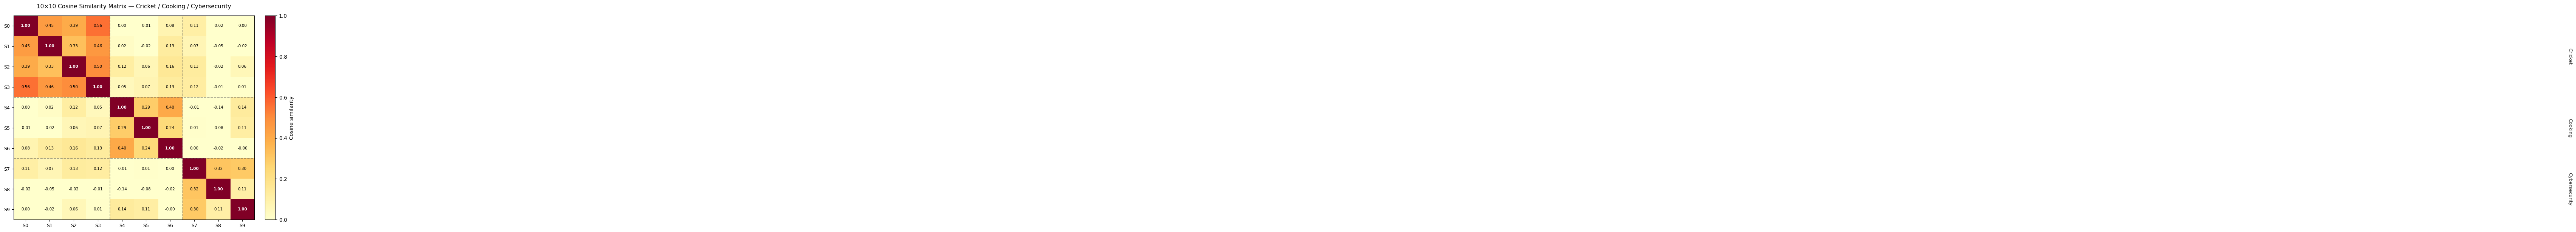

✓ Heatmap saved as heatmap.png


In [5]:
# Compute pairwise cosine similarities
sim_matrix = cosine_similarity(embeddings)  # shape (10, 10)

# ── Print numeric matrix ────────────────────────────────
labels = [f'S{i}' for i in range(10)]
print('Cosine Similarity Matrix (10\u00d710):')
print('       ' + ''.join(f' {l:>5}' for l in labels))
for i, row in enumerate(sim_matrix):
    print(f'  {labels[i]:3s} |' + ''.join(f' {v:5.3f}' for v in row))

# ── Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(10):
    for j in range(10):
        val = sim_matrix[i, j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=color,
                fontweight='bold' if i == j else 'normal')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine similarity', fontsize=10)

ax.set_title(
    '10\u00d710 Cosine Similarity Matrix \u2014 Cricket / Cooking / Cybersecurity',
    fontsize=11, pad=14)

for pos in [3.5, 6.5]:
    ax.axhline(pos, color='#555', lw=1.2, ls='--', alpha=0.6)
    ax.axvline(pos, color='#555', lw=1.2, ls='--', alpha=0.6)

for label, y in [('Cricket', 1.5), ('Cooking', 5.0), ('Cybersecurity', 8.0)]:
    ax.text(10.6, y, label, va='center', fontsize=9,
            rotation=270, transform=ax.get_yaxis_transform(), color='#333')

plt.tight_layout()
plt.savefig('heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('\u2713 Heatmap saved as heatmap.png')


## 6 · Query: find top 2 most similar sentences

In [7]:
query = "The bowler took three wickets in one over"

# Embed query and compute similarity against all 10 sentences
query_embedding = model.encode([query])
query_sims = cosine_similarity(query_embedding, embeddings)[0]

# Rank and pick top 2
top2_indices = np.argsort(query_sims)[::-1][:2]

print(f'Query: "{query}"')
print('\u2500' * 60)
print('Top 2 most similar sentences:\n')
for rank, idx in enumerate(top2_indices, 1):
    topic = topic_labels[idx]
    print(f'  Rank {rank} | Similarity: {query_sims[idx]:.4f}')
    print(f'  Topic: {topic}')
    print(f'  Sentence [{idx}]: "{sentences[idx]}"')
    print()


Query: "The bowler took three wickets in one over"
────────────────────────────────────────────────────────────
Top 2 most similar sentences:

  Rank 1 | Similarity: 0.5592
  Topic: Cricket
  Sentence [1]: "India won the test match by an innings and fifty runs."

  Rank 2 | Similarity: 0.5569
  Topic: Cricket
  Sentence [0]: "The batsman hit a stunning six over the boundary."

